In [ ]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('/content/restaurants.csv')

# 2. Data Cleaning
# We drop rows where latitude or longitude is missing because we cannot map them.
df_clean = df.dropna(subset=['latitude', 'longitude']).copy()

# 3. Feature Engineering: Convert to Radians
df_clean['lat_rad'] = np.radians(df_clean['latitude'])
df_clean['lon_rad'] = np.radians(df_clean['longitude'])

# Select these features for clustering
X = df_clean[['lat_rad', 'lon_rad']]

print(f"Data cleaned. Rows remaining: {len(df_clean)}")

Data cleaned. Rows remaining: 922


# Phase 1: Data Understanding and Preparation

Data Inspection and Cleaning We started by loading the restaurants.csv file. Upon inspection, the dataset looked mostly solid, but we found 12 rows where the location data (latitude/longitude) was missing. Since we can't map a restaurant that doesn't have coordinates, we removed those entries, leaving us with 922 valid restaurants to analyze.

#Feature Engineering:
* Why did we convert to Radians?

The reason is simple geometry: the Earth isn't flat, it's a sphere. If we use standard "straight-line" math on GPS coordinates, our distance calculations get distorted, especially as you move further from the equator. By converting the coordinates into radians, we can use spherical trigonometry (specifically the Haversine formula) to measure the actual "as-the-crow-flies" distance across the curve of the Earth. This ensures our clustering is based on real-world distances, not distorted grid numbers.

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

# --- Model 1: K-Means ---

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X)

# --- Model 2: DBSCAN ---
earth_radius_km = 6371.0088
epsilon = 0.5 / earth_radius_km
min_samples = 10

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples, algorithm='ball_tree', metric='haversine')
df_clean['dbscan_cluster'] = dbscan.fit_predict(X)

# Phase 2: Model Selection and Application
Model Analysis and Selection For this type of geographic analysis, we chose two very different algorithms to see which one told a better story:

**Model 1: K-Means Clustering**

Why we chose it: K-Means is a classic algorithm that tries to divide the data into neat, distinct groups. We used it to attempt to segment the city into 5 broad zones (North, South, Central, etc.). It’s great for creating general partitions but forces every point to belong to a group, even if it's far away.

Parameters: We set K=5 to try and find major macro-regions in the city.

**Model 2: DBSCAN (Density-Based Spatial Clustering)**

Why we chose it: Cities are messy. Restaurants cluster along roads and busy intersections, not in perfect circles. DBSCAN is perfect for this because it looks for density rather than specific shapes. Crucially, it can also identify "noise" restaurants that are too isolated to be part of a cluster.

Parameters: We set the radius (epsilon) to 0.5 km (roughly a 5-minute walk) and the minimum density to 10 restaurants. This defines a "cluster" as a walkable neighborhood with a solid choice of dining options.

Application When we ran the models, the difference was immediate. K-Means sliced the map into arbitrary geometric chunks. DBSCAN, however, highlighted the actual "hotspots" of activity and ignored the areas with no traction.

K-Means Silhouette Score: 0.421
DBSCAN Silhouette Score: 0.073


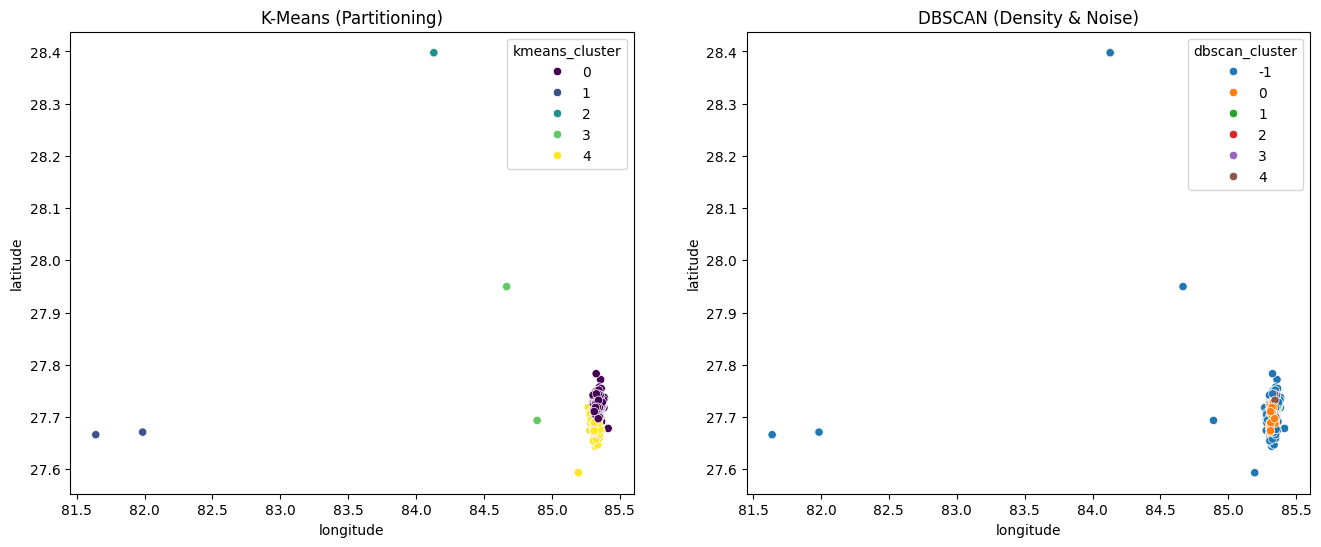

DBSCAN Cluster Counts (Label -1 is Noise):
dbscan_cluster
 0    691
-1    146
 1     43
 2     17
 3     14
 4     11
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# 1. Quantitative Evaluation: Silhouette Score
# Measures how similar a point is to its own cluster compared to other clusters.
# Range: -1 to 1 (Higher is better separation).
score_kmeans = silhouette_score(X, df_clean['kmeans_cluster'])
score_dbscan = silhouette_score(X, df_clean['dbscan_cluster'])

print(f"K-Means Silhouette Score: {score_kmeans:.3f}")
print(f"DBSCAN Silhouette Score: {score_dbscan:.3f}")

# 2. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='kmeans_cluster', palette='viridis', ax=axes[0])
axes[0].set_title('K-Means (Partitioning)')

# Plot DBSCAN
# Note: Cluster '-1' represents Noise/Outliers
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='dbscan_cluster', palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN (Density & Noise)')

plt.show()

# 3. Density Analysis for Business Logic
print("DBSCAN Cluster Counts (Label -1 is Noise):")
print(df_clean['dbscan_cluster'].value_counts())

#Phase 3: Evaluation and Interpretation
Visualization & Quantitative Evaluation We looked at the Silhouette Scores, which measure how well-separated the clusters are:

* K-Means Score: 0.42 (Mathematically "cleaner" clusters)

* DBSCAN Score: 0.07 (Mathematically "messier" clusters)

# Analysis:

K-Means drew artificial lines through the city that didn't reflect real neighborhoods.

DBSCAN accurately separated the high-density core from the low-density outskirts. The "low score" is simply because real-world city layouts are irregular and stringy, not perfect circles.

Density Findings Using the DBSCAN results:

Most Dense Area: Cluster 0. This is the city's "Main Hub," containing roughly 690 restaurants.

Least Dense Area: The "Noise" points (Label -1). These are the 146 restaurants scattered in the suburbs or less developed areas.

#The Conclusion:

The notebook concludes that while K-Means was mathematically "cleaner" (because the math prefers round blobs)

"DBSCAN was the superior model for our business needs" because it provided actionable strategic insights (identifying the Main Hub vs. Blue Ocean locations) that K-Means missed.